In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

In [18]:
master_df = pd.read_csv("../data/processed/master_dataset_v2.csv")
df = master_df.copy()

In [19]:
df_no_dc = df[df["state"] != "District of Columbia"].copy()

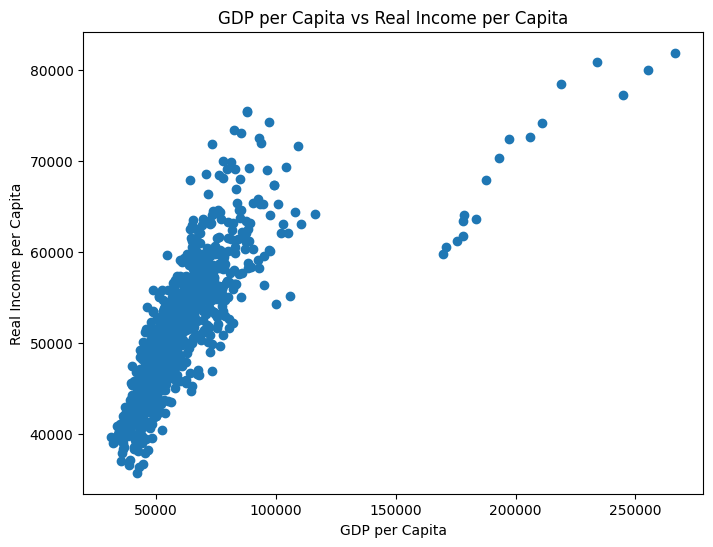

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(df["gdp_pc"], df["real_income_pc"])
plt.xlabel("GDP per Capita")
plt.ylabel("Real Income per Capita")
plt.title("GDP per Capita vs Real Income per Capita")
plt.show()

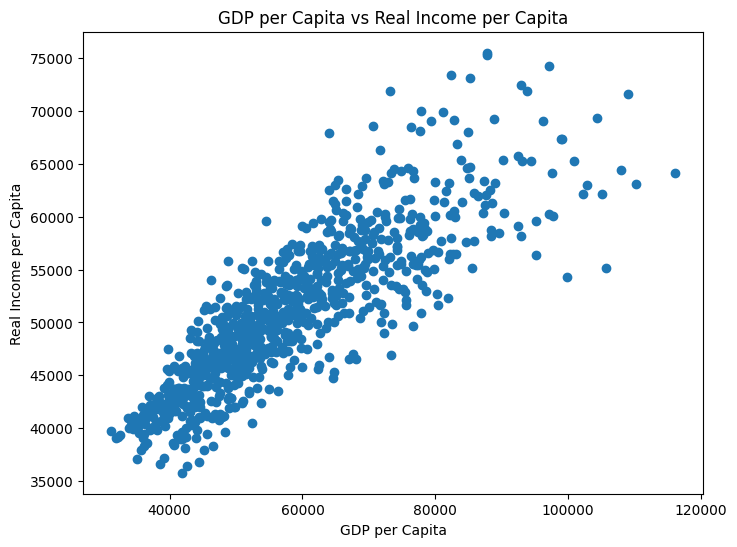

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(df_no_dc["gdp_pc"], df_no_dc["real_income_pc"])
plt.xlabel("GDP per Capita")
plt.ylabel("Real Income per Capita")
plt.title("GDP per Capita vs Real Income per Capita")
plt.show()

In [22]:
df_no_dc["gdp_pc"].corr(df_no_dc["real_income_pc"])

np.float64(0.8490984837865733)

In [24]:
import statsmodels.api as sm

# Perform linear regression
X = df_no_dc[['gdp_pc']]
y = df_no_dc['real_income_pc']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         real_income_pc   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     2191.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          2.92e-237
Time:                        17:42:21   Log-Likelihood:                -8224.9
No. Observations:                 850   AIC:                         1.645e+04
Df Residuals:                     848   BIC:                         1.646e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.696e+04    530.323     50.829      0.0

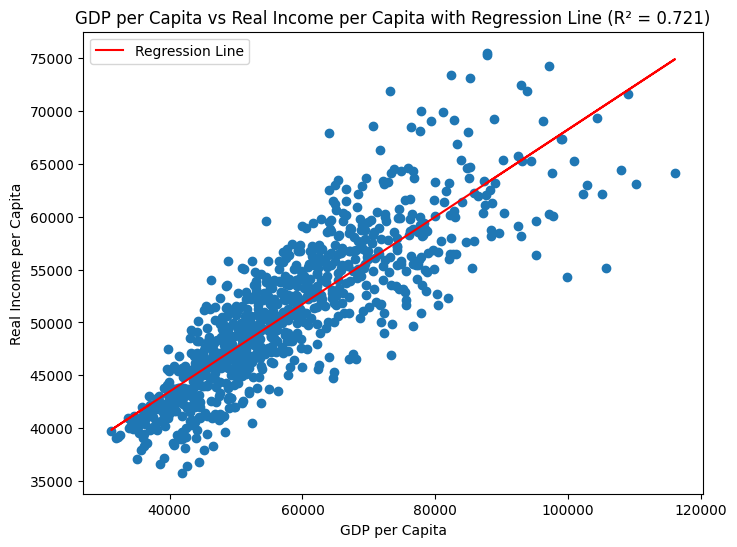

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(df_no_dc["gdp_pc"], df_no_dc["real_income_pc"])
plt.plot(df_no_dc["gdp_pc"], model.predict(X), color='red', label='Regression Line')
plt.xlabel("GDP per Capita")
plt.ylabel("Real Income per Capita")
plt.title(f"GDP per Capita vs Real Income per Capita with Regression Line (R² = {model.rsquared:.3f})")
plt.legend()
plt.show()

In [26]:
df_no_dc["predicted"] = model.predict(X)
df_no_dc["residual"] = df_no_dc["real_income_pc"] - df_no_dc["predicted"]

In [27]:
# worst
df_no_dc.sort_values("residual").head(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
135,Delaware,2024,1050123.0,1.109718e+11,105675.05,674338.0,0.642151,68061.0,55185.0,99.808,70587.560320,-15402.560320
134,Delaware,2023,1035354.0,1.033325e+11,99804.03,669568.0,0.646704,64591.0,54314.0,98.759,68163.492021,-13849.492021
560,New York,2024,20001419.0,2.322139e+12,116098.71,13312196.0,0.665563,85552.0,64153.0,107.921,74891.354849,-10738.354849
125,Delaware,2014,935278.0,6.860600e+10,73353.59,556449.0,0.594956,45359.0,46900.0,99.708,57242.447113,-10342.447113
133,Delaware,2022,1020279.0,9.703040e+10,95101.83,642859.0,0.630082,64066.0,56371.0,98.007,66222.014399,-9851.014399
559,New York,2023,19786543.0,2.182549e+12,110304.72,13181774.0,0.666199,81932.0,63093.0,107.842,72499.091242,-9406.091242
126,Delaware,2015,944716.0,7.235250e+10,76586.51,568832.0,0.602120,47238.0,49667.0,97.913,58577.278008,-8910.278008
121,Delaware,2010,899773.0,5.813220e+10,64607.63,522361.0,0.580548,41100.0,44778.0,101.545,53631.353236,-8853.353236
203,Hawaii,2024,1434952.0,1.176274e+11,81973.06,928210.0,0.646858,71019.0,52272.0,109.951,60801.314903,-8529.314903
751,Utah,2011,2818798.0,1.251378e+11,44394.03,1664413.0,0.590469,34015.0,36773.0,99.813,45285.418976,-8512.418976


In [28]:
# best
df_no_dc.sort_values("residual").tail(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
713,South Dakota,2024,927110.0,7.679580e+10,82833.54,662833.0,0.714945,75699.0,69153.0,88.586,61156.595977,7996.404023
106,Connecticut,2012,3605215.0,2.399075e+11,66544.58,2223243.0,0.616674,63556.0,62569.0,107.595,54431.094863,8137.905137
454,Montana,2020,1087156.0,5.305730e+10,48803.76,683414.0,0.628626,53569.0,55801.0,91.972,47106.139515,8694.860485
112,Connecticut,2018,3611229.0,2.805354e+11,77684.19,2314465.0,0.640908,72159.0,68121.0,104.015,59030.495897,9090.504103
709,South Dakota,2020,887808.0,5.684730e+10,64031.07,606045.0,0.682631,59586.0,62511.0,91.320,53393.299061,9117.700939
105,Connecticut,2011,3594181.0,2.330587e+11,64843.34,2206253.0,0.613840,62964.0,63006.0,107.834,53728.674849,9277.325151
113,Connecticut,2019,3607133.0,2.864519e+11,79412.62,2297925.0,0.637050,74176.0,69091.0,103.915,59744.142311,9346.857689
712,South Dakota,2023,917739.0,7.445880e+10,81132.87,657822.0,0.716785,74155.0,69861.0,88.149,60454.411308,9406.588692
104,Connecticut,2010,3580281.0,2.340222e+11,65364.20,2171940.0,0.606640,61392.0,63477.0,106.999,53943.731213,9533.268787
506,New Hampshire,2021,1387907.0,9.943330e+10,71642.62,894652.0,0.644605,73982.0,66325.0,102.568,56536.009707,9788.990293


In [29]:
state_avg = df_no_dc.groupby("state")["residual"].mean().sort_values()

In [ ]:
#worst
state_avg.head(10)

state
Delaware     -8393.715627
Hawaii       -6125.751932
Utah         -5595.845847
New York     -4906.533935
California   -3935.847055
Alaska       -3746.189770
Arizona      -3554.967680
Georgia      -3381.989238
New Mexico   -3368.695181
Washington   -3295.035881
Name: residual, dtype: float64

In [31]:
#best
state_avg.tail(10)

state
Vermont          2409.601663
Massachusetts    2704.149113
Montana          2962.843058
Kansas           2983.739474
North Dakota     3052.749163
Oklahoma         3251.896246
New Hampshire    3666.230349
Wyoming          5835.133003
South Dakota     6504.316347
Connecticut      7884.458098
Name: residual, dtype: float64

In [32]:
df_no_dc["gdp_group"] = pd.qcut(df_no_dc["gdp_pc"], 4, labels=["Low", "Mid-Low", "Mid-High", "High"])
df_no_dc.groupby("gdp_group")["residual"].mean()

gdp_group
Low        -1034.067427
Mid-Low      226.847019
Mid-High    1154.124503
High        -340.420661
Name: residual, dtype: float64

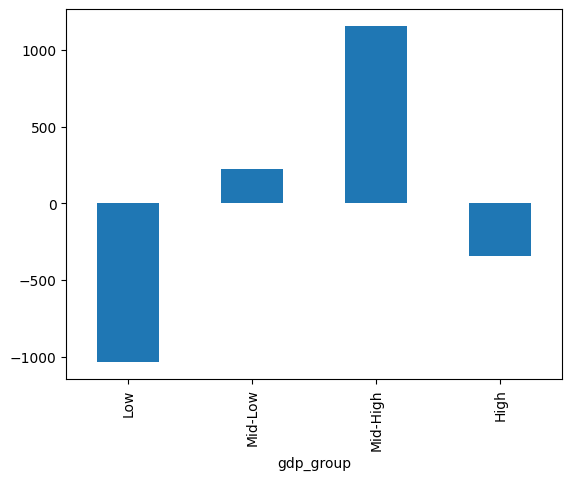

In [34]:
ax = df_no_dc.groupby("gdp_group")["residual"].mean().plot(kind="bar")

In [36]:
groups = [group["residual"].values for name, group in df_no_dc.groupby("gdp_group")]

f_stat, p_value = stats.f_oneway(*groups)
print(p_value)

3.85128055055968e-08


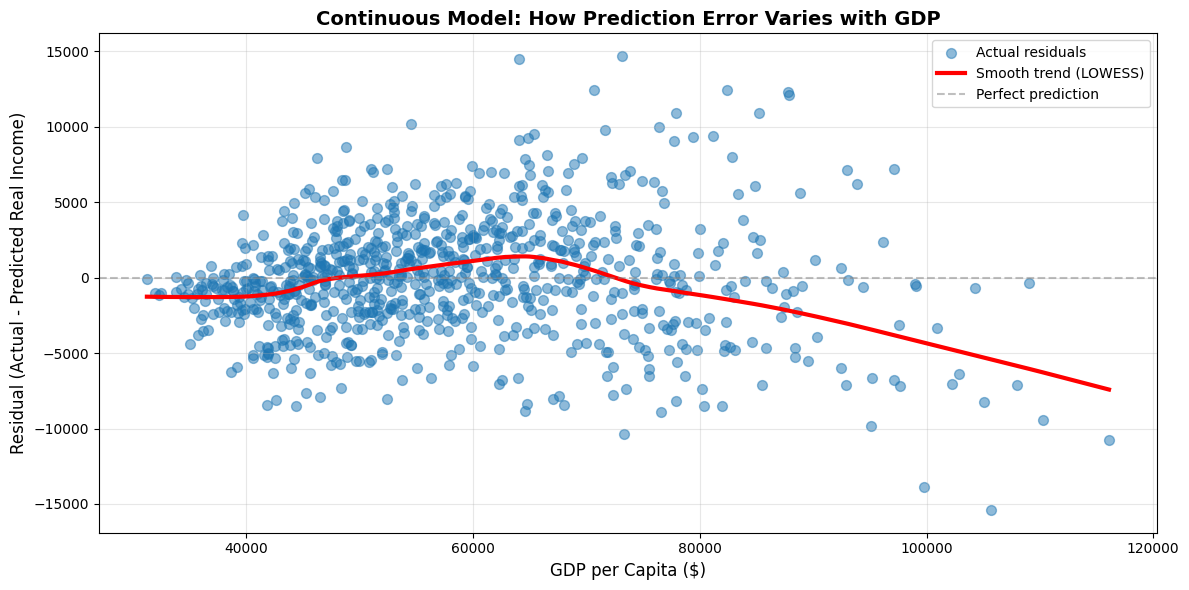

Interpretation: Positive residuals = states earning MORE than GDP predicts
                Negative residuals = states earning LESS than GDP predicts


In [37]:
# Continuous model: smooth relationship between GDP and residuals
from scipy.interpolate import make_interp_spline

# Sort by GDP for plotting
df_sorted = df_no_dc.sort_values('gdp_pc')

# Create a smoother using LOWESS (locally weighted scatterplot smoothing)
from statsmodels.nonparametric.smoothers_lowess import lowess

# Apply LOWESS to residuals vs GDP
residual_smooth = lowess(df_sorted['residual'], df_sorted['gdp_pc'], frac=0.3)

# Plot continuous relationship
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot
ax.scatter(df_no_dc['gdp_pc'], df_no_dc['residual'], alpha=0.5, label='Actual residuals', s=50)

# LOWESS smooth curve
ax.plot(residual_smooth[:, 0], residual_smooth[:, 1], 'r-', linewidth=3, label='Smooth trend (LOWESS)')

# Reference line at y=0 (perfect prediction)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Perfect prediction')

ax.set_xlabel('GDP per Capita ($)', fontsize=12)
ax.set_ylabel('Residual (Actual - Predicted Real Income)', fontsize=12)
ax.set_title('Continuous Model: How Prediction Error Varies with GDP', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: Positive residuals = states earning MORE than GDP predicts")
print("                Negative residuals = states earning LESS than GDP predicts")

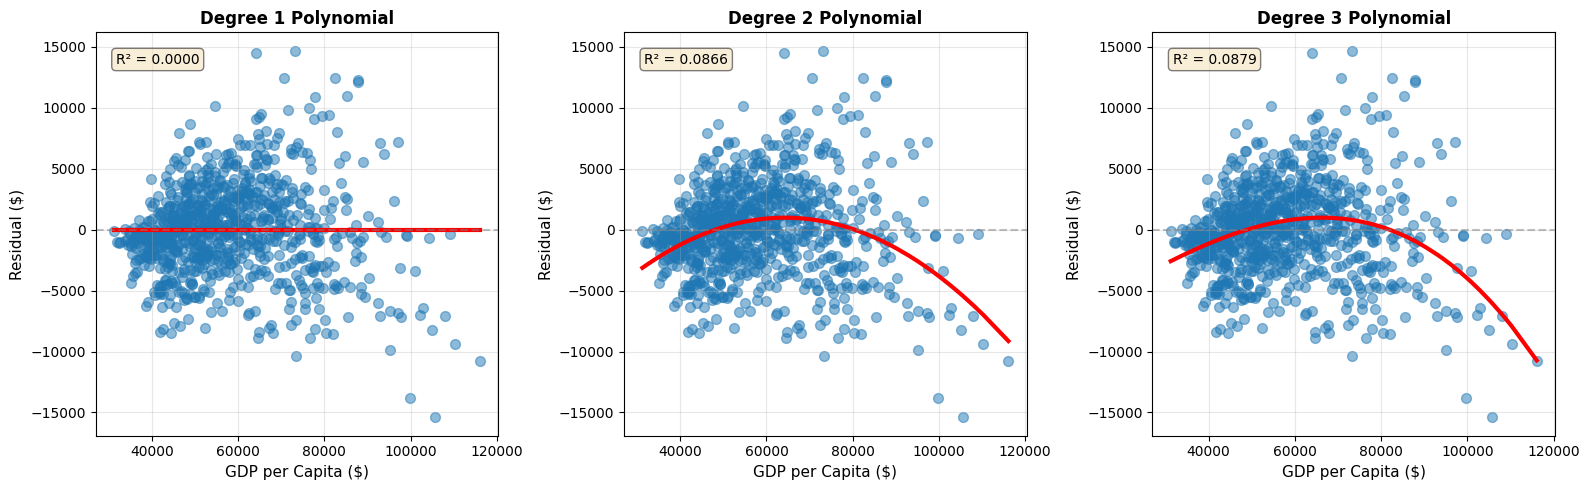

Model Comparison:
Degree 1: R² = 0.0000
Degree 2: R² = 0.0866
Degree 3: R² = 0.0879


In [38]:
# Polynomial regression model to capture non-linearity
from numpy.polynomial import polynomial as P

# Fit polynomial models of different degrees
degrees = [1, 2, 3]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, deg in enumerate(degrees):
    ax = axes[idx]
    
    # Fit polynomial
    coeffs = np.polyfit(df_no_dc['gdp_pc'], df_no_dc['residual'], deg)
    poly = np.poly1d(coeffs)
    
    # Sort for smooth plotting
    gdp_sorted = np.sort(df_no_dc['gdp_pc'].values)
    residual_pred = poly(gdp_sorted)
    
    # Plot
    ax.scatter(df_no_dc['gdp_pc'], df_no_dc['residual'], alpha=0.5, s=50)
    ax.plot(gdp_sorted, residual_pred, 'r-', linewidth=3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('GDP per Capita ($)', fontsize=11)
    ax.set_ylabel('Residual ($)', fontsize=11)
    ax.set_title(f'Degree {deg} Polynomial', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Calculate R² for this model
    y_pred = poly(df_no_dc['gdp_pc'])
    ss_res = np.sum((df_no_dc['residual'] - y_pred) ** 2)
    ss_tot = np.sum((df_no_dc['residual'] - df_no_dc['residual'].mean()) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    ax.text(0.05, 0.95, f'R² = {r_squared:.4f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Model Comparison:")
for deg in degrees:
    coeffs = np.polyfit(df_no_dc['gdp_pc'], df_no_dc['residual'], deg)
    poly = np.poly1d(coeffs)
    y_pred = poly(df_no_dc['gdp_pc'])
    ss_res = np.sum((df_no_dc['residual'] - y_pred) ** 2)
    ss_tot = np.sum((df_no_dc['residual'] - df_no_dc['residual'].mean()) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"Degree {deg}: R² = {r_squared:.4f}")